In [1]:
import pandas as pd
import numpy as np

In [2]:
df = pd.read_csv('../data/data1.csv', sep = ';')

pd.set_option('display.max_columns', None) 
pd.set_option('display.max_rows', None)  


In [3]:
sectors_list = []
for letter in df['SEK_PKD7'].unique():
    # Create a mask for the current letter
    mask = df['SEK_PKD7'] == letter
    
    # Create a new column named 'SEK_<LETTER>', assigning 1 if the mask is True, else 0
    df[f'SEK_{letter}'] = np.where(mask, 1, 0)
    sectors_list.append(f'SEK_{letter}') 

In [4]:
print(sectors_list)

['SEK_S', 'SEK_A', 'SEK_G', 'SEK_C', 'SEK_M', 'SEK_Q', 'SEK_P', 'SEK_F', 'SEK_L', 'SEK_R', 'SEK_D', 'SEK_H', 'SEK_I', 'SEK_J', 'SEK_N', 'SEK_K', 'SEK_E', 'SEK_O', 'SEK_B', 'SEK_U', 'SEK_T', 'SEK_-']


In [5]:
df['SEK_PKD7'].value_counts()

A    253514
G    191442
M     97762
F     71579
C     58824
S     45101
H     44894
J     38822
Q     32988
L     32056
P     26746
N     26526
K     24606
I     18223
R     11847
O      3471
E      2359
D      1944
B       862
U       144
T         5
-         4
Name: SEK_PKD7, dtype: int64

In [6]:
vars_list = ['COREfirms', 'COREpopul', 'dist_core_10', 'dist_core_25', 'dist_core_50', 'dist_midsize_10', 'dist_midsize_25', 'dist_midsize_50',
             'dist_regional_10', 'dist_regional_25', 'dist_regional_50', 'dist_localbig_10', 'dist_localbig_25', 'dist_localbig_50',
             'dist_localsmall_10', 'dist_localsmall_25', 'dist_localsmall_50']

results_dfs = {}
percentages_matching  = {}

for sek in sectors_list:
    results = []
    for var in vars_list:
        cross_tab = pd.crosstab(df[sek], df[var])
        non_other_obs = cross_tab.index != 0
        matching_obs = cross_tab[1][non_other_obs].sum()
        total_non_other_obs = cross_tab[1][non_other_obs].sum() + cross_tab[0][non_other_obs].sum()
        percentage_matching = (matching_obs / total_non_other_obs) * 100
        percentage_all = (matching_obs / df.shape[0]) * 100

        result_dict = {
            'Variable': var,
            'Percentage Matching': f"{percentage_matching:.2f}%",
            'Percentage All': f"{percentage_all:.2f}%",
            f'is_{sek} (0)': cross_tab.iloc[0, 0],
            f'is_{sek} (1)': cross_tab.iloc[0, 1],
        }

        results.append(result_dict)

    results_df = pd.DataFrame(results)
    results_dfs[f'results_{sek}'] = results_df
    
    display(results_df)


,Variable,Percentage Matching,Percentage All,is_SEK_S (0),is_SEK_S (1)
0,COREfirms,86.32%,3.96%,296666,641952
1,COREpopul,90.90%,4.17%,240145,698473
2,dist_core_10,46.25%,2.12%,630877,307741
3,dist_core_25,66.42%,3.04%,448797,489821
4,dist_core_50,75.66%,3.47%,339039,599579
5,dist_midsize_10,3.84%,0.18%,909725,28893
6,dist_midsize_25,7.50%,0.34%,858357,80261
7,dist_midsize_50,11.65%,0.53%,787607,151011
8,dist_regional_10,8.82%,0.40%,865373,73245
9,dist_regional_25,63.76%,2.92%,446775,491843


,Variable,Percentage Matching,Percentage All,is_SEK_A (0),is_SEK_A (1)
0,COREfirms,20.71%,5.34%,101830,628375
1,COREpopul,31.39%,8.09%,70316,659889
2,dist_core_10,3.45%,0.89%,410363,319842
3,dist_core_25,9.13%,2.35%,233575,496630
4,dist_core_50,27.03%,6.97%,165040,565165
5,dist_midsize_10,2.27%,0.59%,705342,24863
6,dist_midsize_25,11.31%,2.92%,675238,54967
7,dist_midsize_50,29.26%,7.54%,648115,82090
8,dist_regional_10,4.73%,1.22%,664975,65230
9,dist_regional_25,22.09%,5.69%,265594,464611


,Variable,Percentage Matching,Percentage All,is_SEK_G (0),is_SEK_G (1)
0,COREfirms,84.28%,16.40%,272732,519545
1,COREpopul,88.56%,17.23%,222348,569929
2,dist_core_10,38.21%,7.44%,536825,255452
3,dist_core_25,63.24%,12.31%,393577,398700
4,dist_core_50,73.77%,14.36%,299812,492465
5,dist_midsize_10,3.86%,0.75%,769038,23239
6,dist_midsize_25,8.97%,1.75%,725804,66473
7,dist_midsize_50,13.51%,2.63%,661871,130406
8,dist_regional_10,9.30%,1.81%,732848,59429
9,dist_regional_25,61.26%,11.92%,388948,403329


,Variable,Percentage Matching,Percentage All,is_SEK_C (0),is_SEK_C (1)
0,COREfirms,79.75%,4.77%,290920,633975
1,COREpopul,86.41%,5.17%,236251,688644
2,dist_core_10,33.56%,2.01%,616037,308858
3,dist_core_25,60.33%,3.61%,440608,484287
4,dist_core_50,71.61%,4.28%,333317,591578
5,dist_midsize_10,4.24%,0.25%,896764,28131
6,dist_midsize_25,10.26%,0.61%,847290,77605
7,dist_midsize_50,15.17%,0.91%,777554,147341
8,dist_regional_10,9.96%,0.60%,853531,71364
9,dist_regional_25,57.24%,3.42%,437964,486931


,Variable,Percentage Matching,Percentage All,is_SEK_M (0),is_SEK_M (1)
0,COREfirms,94.44%,9.39%,297401,588556
1,COREpopul,96.80%,9.62%,241123,644834
2,dist_core_10,57.86%,5.75%,613921,272036
3,dist_core_25,82.54%,8.20%,446879,439078
4,dist_core_50,88.44%,8.79%,338719,547238
5,dist_midsize_10,2.38%,0.24%,857657,28300
6,dist_midsize_25,4.42%,0.44%,806638,79319
7,dist_midsize_50,5.85%,0.58%,735412,150545
8,dist_regional_10,7.78%,0.77%,816335,69622
9,dist_regional_25,71.80%,7.14%,435554,450403


...

,Variable,Percentage Matching,Percentage All,is_SEK_O (0),is_SEK_O (1)
0,COREfirms,32.27%,0.11%,300483,679765
1,COREpopul,41.63%,0.15%,242222,738026
2,dist_core_10,10.05%,0.04%,651999,328249
3,dist_core_25,16.25%,0.06%,461037,519211
4,dist_core_50,30.77%,0.11%,347615,632633
5,dist_midsize_10,2.56%,0.01%,949712,30536
6,dist_midsize_25,10.89%,0.04%,896983,83265
7,dist_midsize_50,27.00%,0.10%,824918,155330
8,dist_regional_10,4.58%,0.02%,903182,77066
9,dist_regional_25,28.55%,0.10%,460638,519610


,Variable,Percentage Matching,Percentage All,is_SEK_B (0),is_SEK_B (1)
0,COREfirms,71.11%,0.06%,302585,680272
1,COREpopul,76.22%,0.07%,244043,738814
2,dist_core_10,42.46%,0.04%,654625,328232
3,dist_core_25,55.57%,0.05%,463561,519296
4,dist_core_50,67.52%,0.06%,349738,633119
5,dist_midsize_10,2.78%,0.00%,952256,30601
6,dist_midsize_25,11.83%,0.01%,899316,83541
7,dist_midsize_50,18.68%,0.02%,826751,156106
8,dist_regional_10,5.80%,0.01%,905682,77175
9,dist_regional_25,56.73%,0.05%,462745,520112


,Variable,Percentage Matching,Percentage All,is_SEK_U (0),is_SEK_U (1)
0,COREfirms,99.31%,0.01%,302833,680742
1,COREpopul,99.31%,0.01%,244247,739328
2,dist_core_10,97.22%,0.01%,655117,328458
3,dist_core_25,97.92%,0.01%,463941,519634
4,dist_core_50,98.61%,0.01%,350016,633559
5,dist_midsize_10,1.39%,0.00%,952952,30623
6,dist_midsize_25,1.39%,0.00%,899934,83641
7,dist_midsize_50,1.39%,0.00%,827310,156265
8,dist_regional_10,0.00%,0.00%,906350,77225
9,dist_regional_25,85.42%,0.01%,463097,520478


,Variable,Percentage Matching,Percentage All,is_SEK_T (0),is_SEK_T (1)
0,COREfirms,80.00%,0.00%,302833,680881
1,COREpopul,80.00%,0.00%,244247,739467
2,dist_core_10,60.00%,0.00%,655119,328595
3,dist_core_25,80.00%,0.00%,463943,519771
4,dist_core_50,100.00%,0.00%,350018,633696
5,dist_midsize_10,0.00%,0.00%,953089,30625
6,dist_midsize_25,0.00%,0.00%,900071,83643
7,dist_midsize_50,0.00%,0.00%,827447,156267
8,dist_regional_10,0.00%,0.00%,906489,77225
9,dist_regional_25,80.00%,0.00%,463117,520597


,Variable,Percentage Matching,Percentage All,is_SEK_- (0),is_SEK_- (1)
0,COREfirms,100.00%,0.00%,302834,680881
1,COREpopul,100.00%,0.00%,244248,739467
2,dist_core_10,100.00%,0.00%,655121,328594
3,dist_core_25,100.00%,0.00%,463944,519771
4,dist_core_50,100.00%,0.00%,350018,633697
5,dist_midsize_10,0.00%,0.00%,953090,30625
6,dist_midsize_25,0.00%,0.00%,900072,83643
7,dist_midsize_50,0.00%,0.00%,827448,156267
8,dist_regional_10,0.00%,0.00%,906490,77225
9,dist_regional_25,100.00%,0.00%,463118,520597


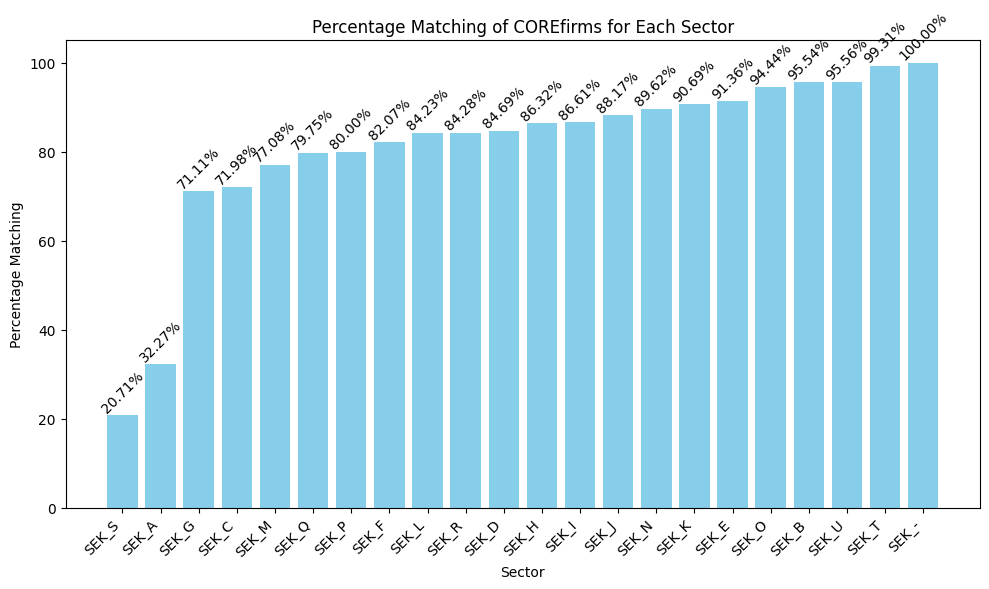

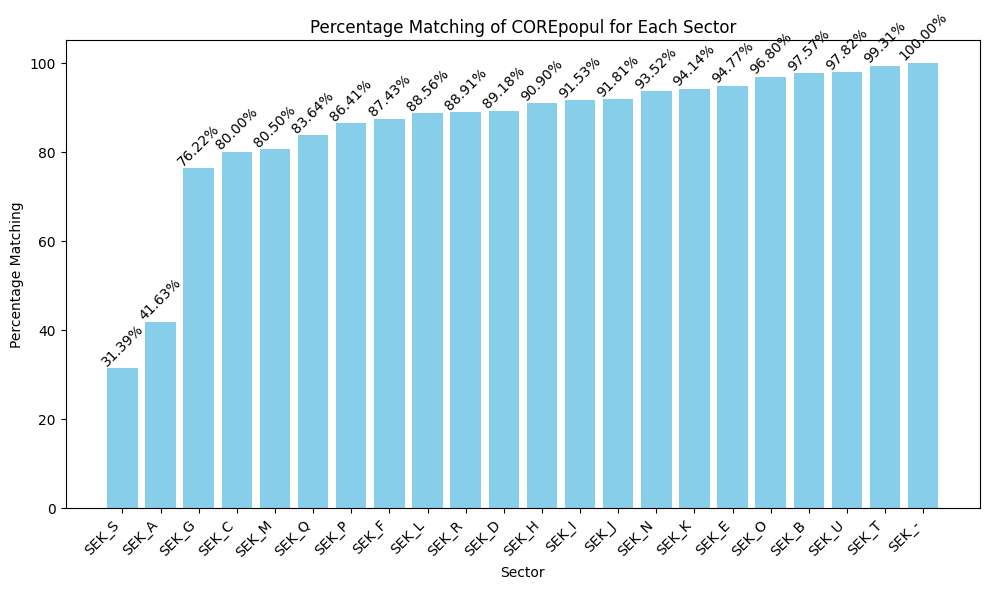

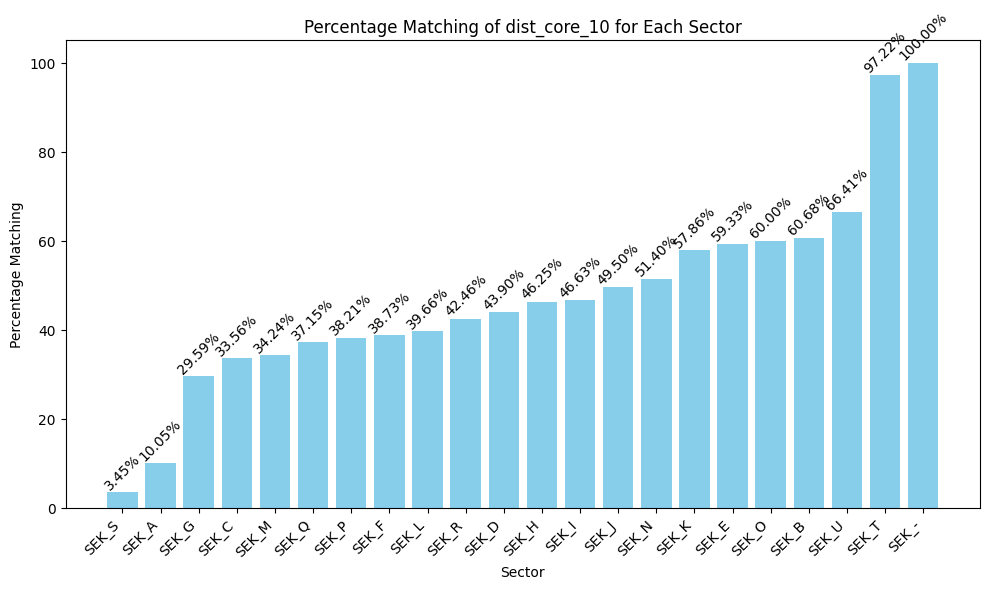

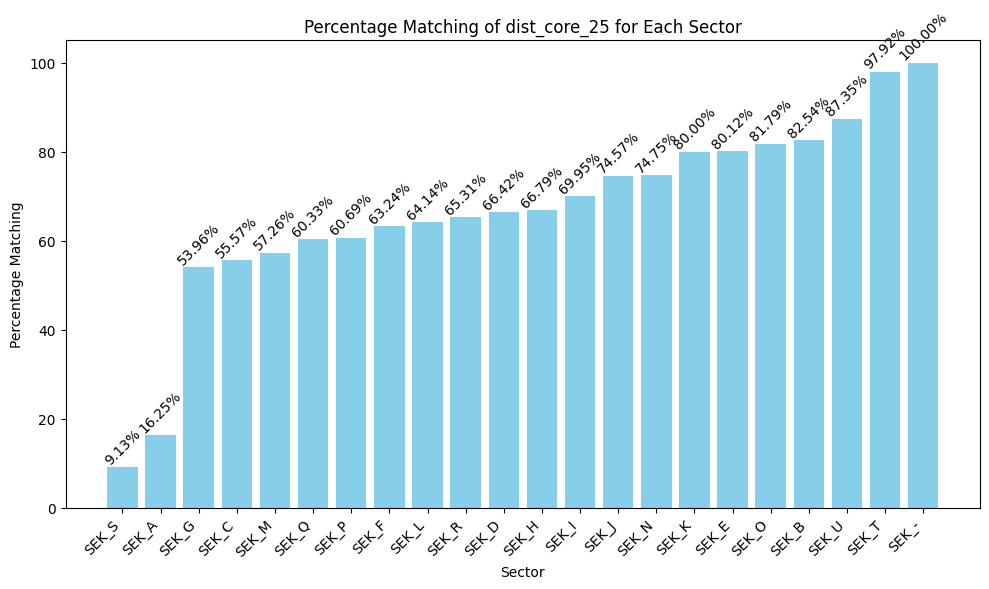

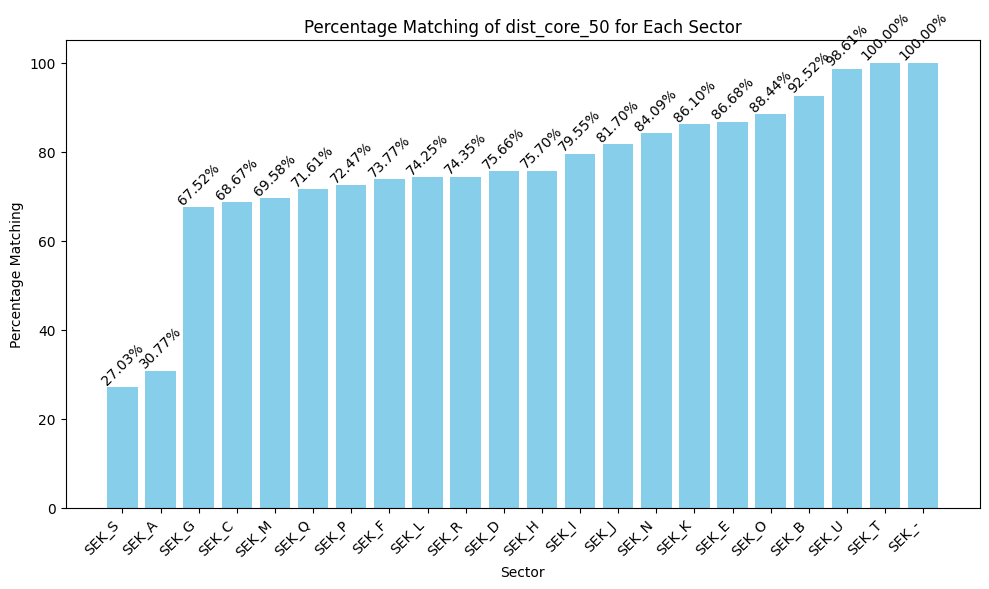

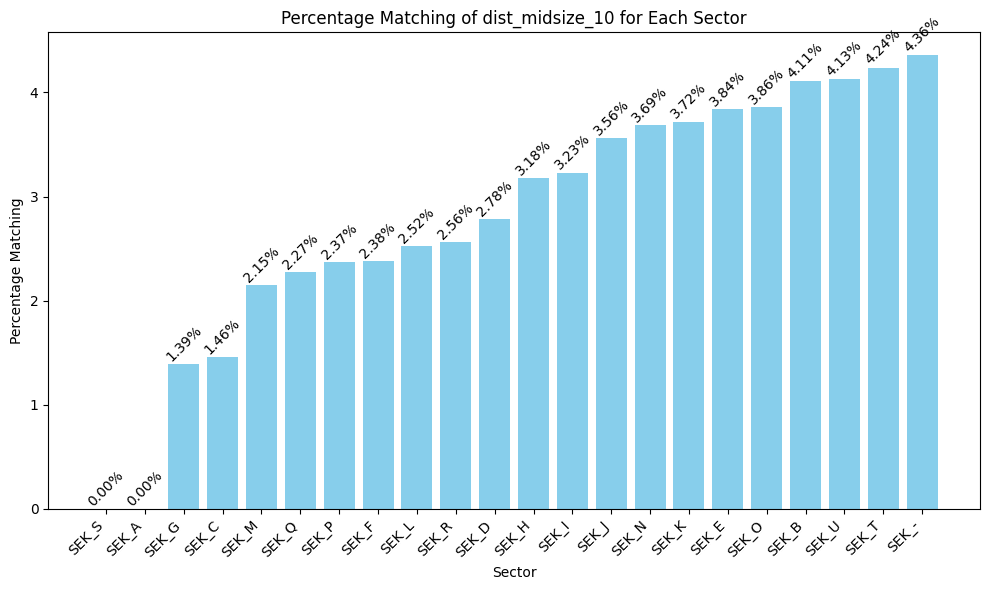

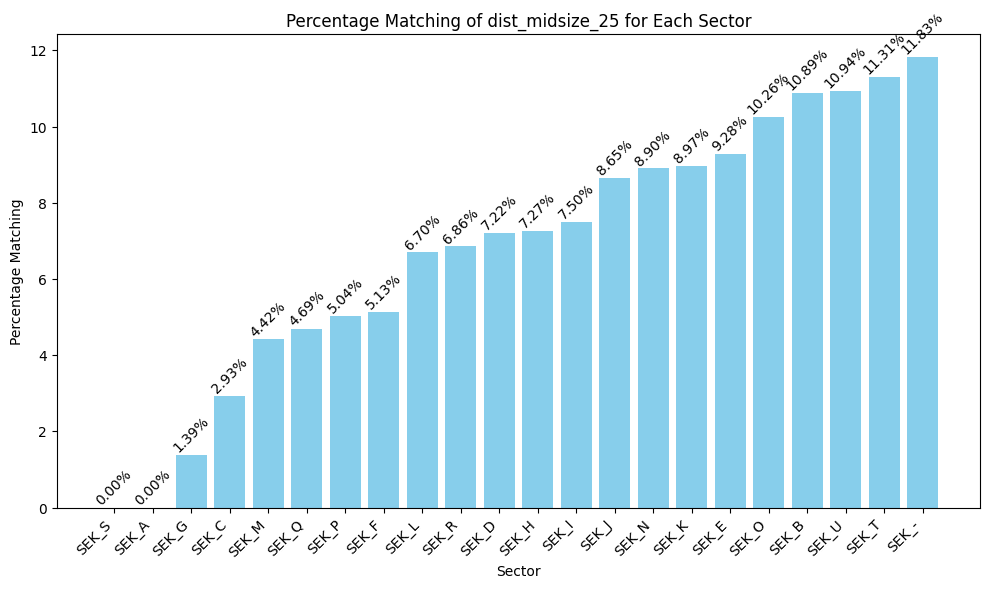

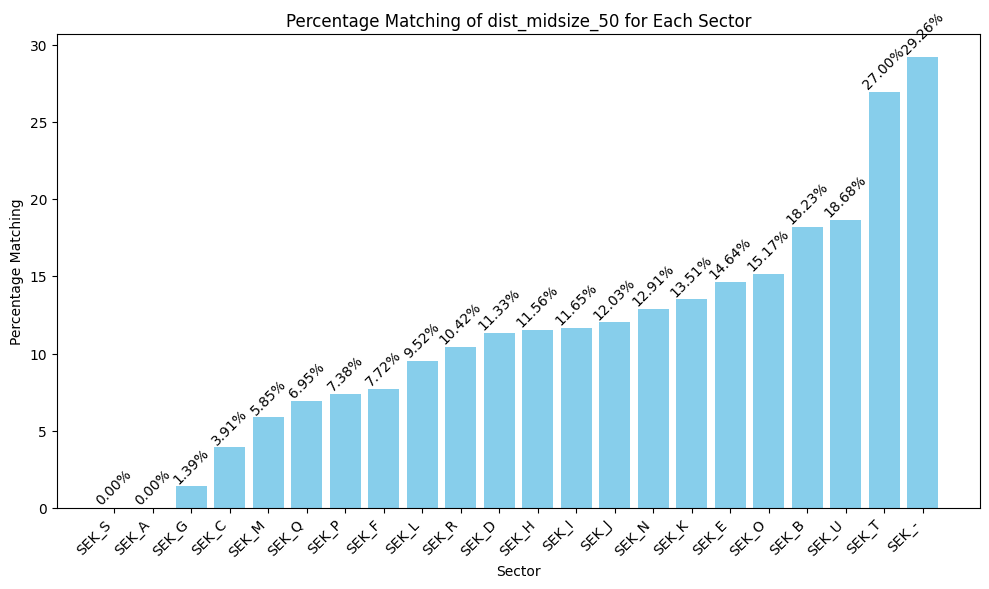

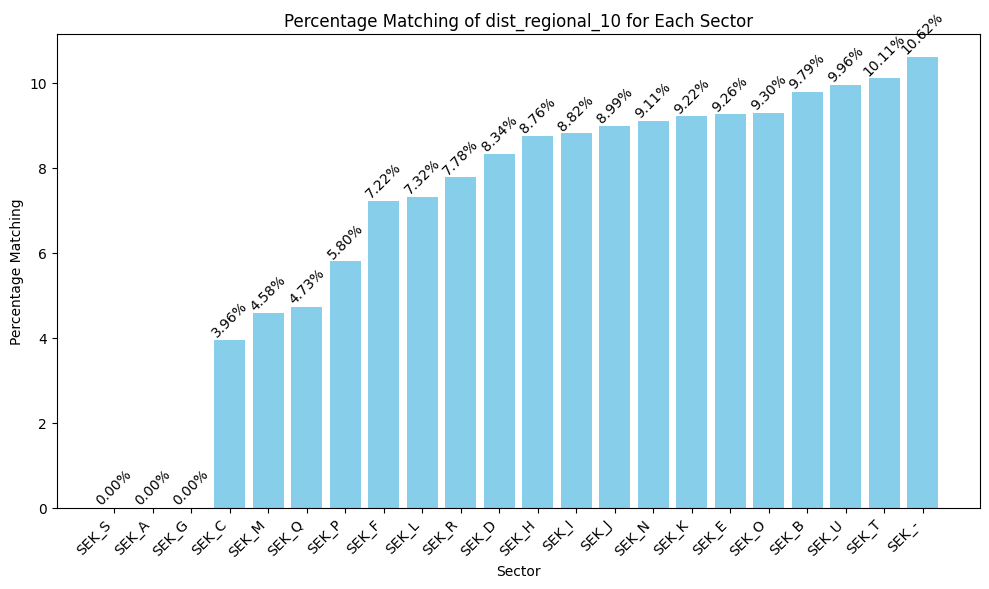

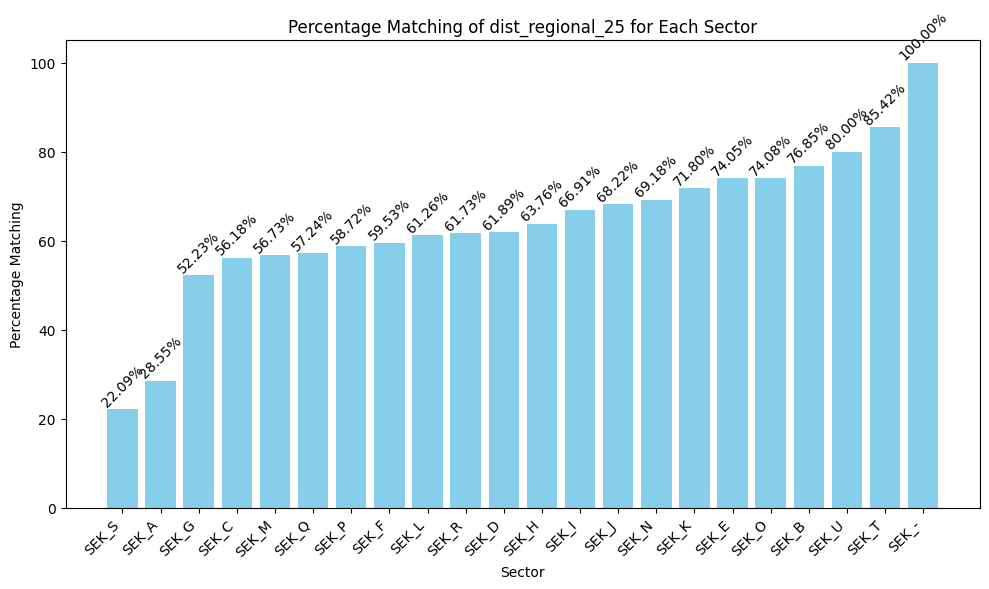

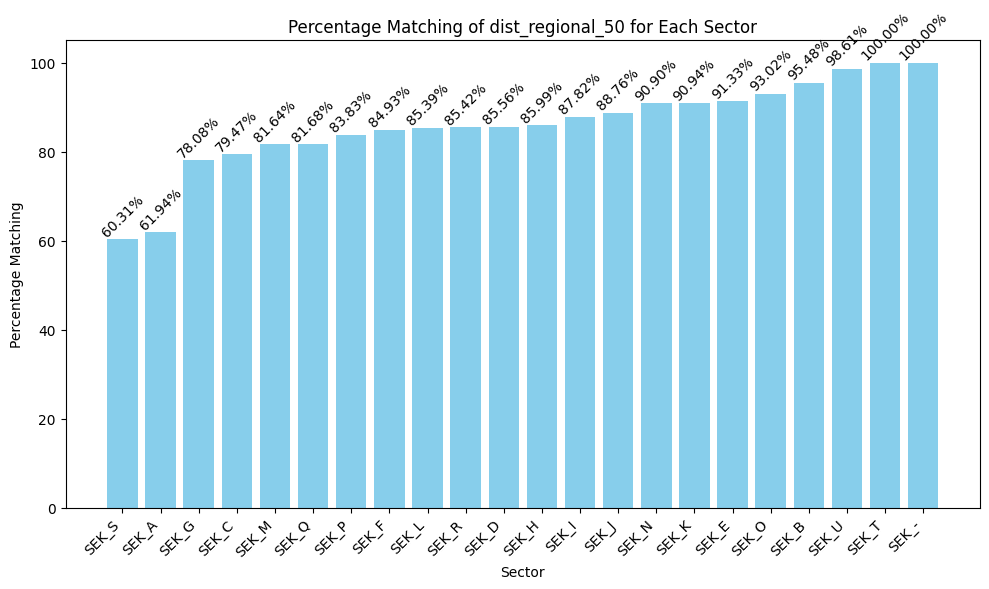

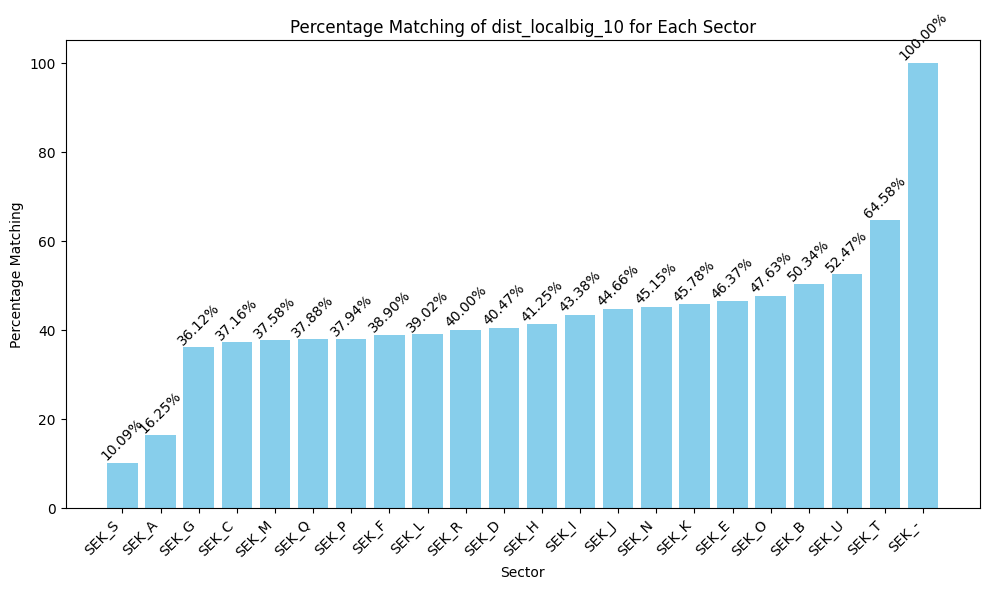

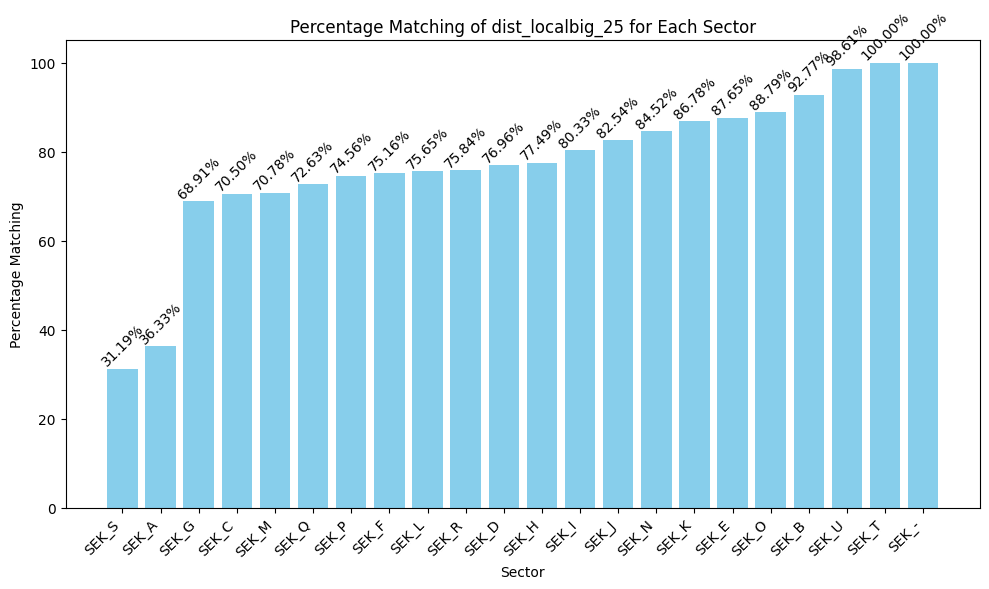

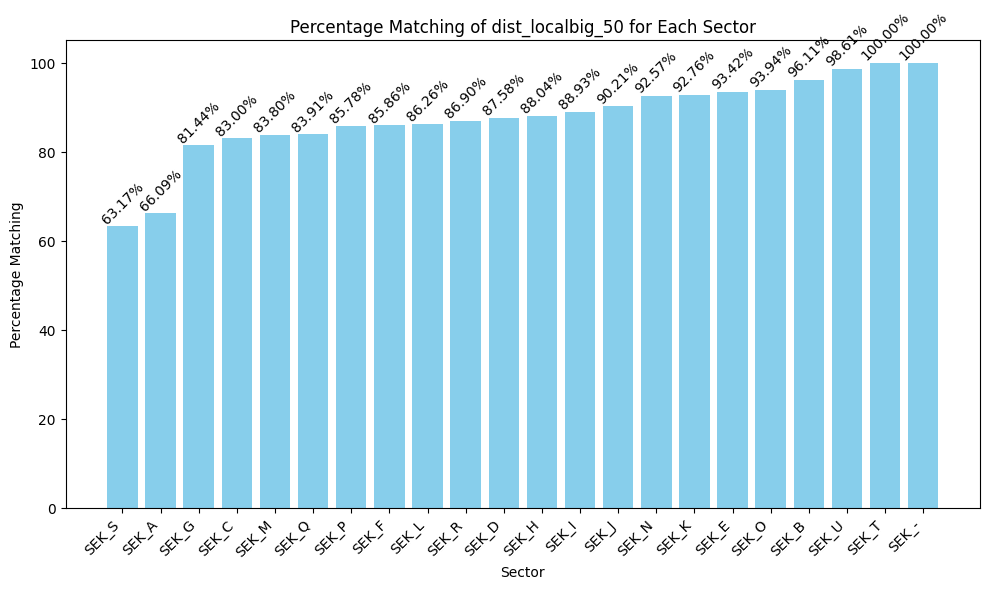

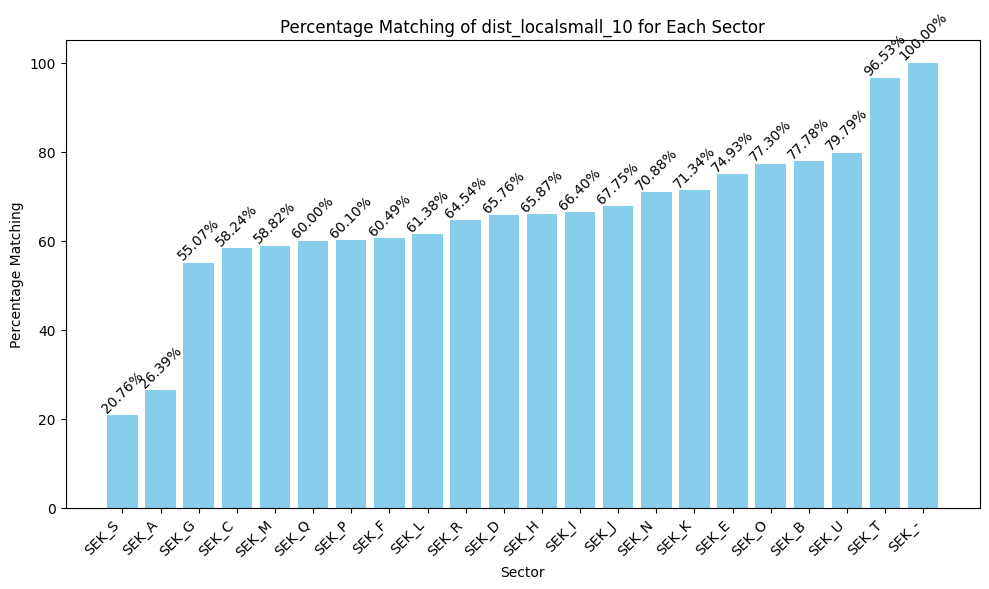

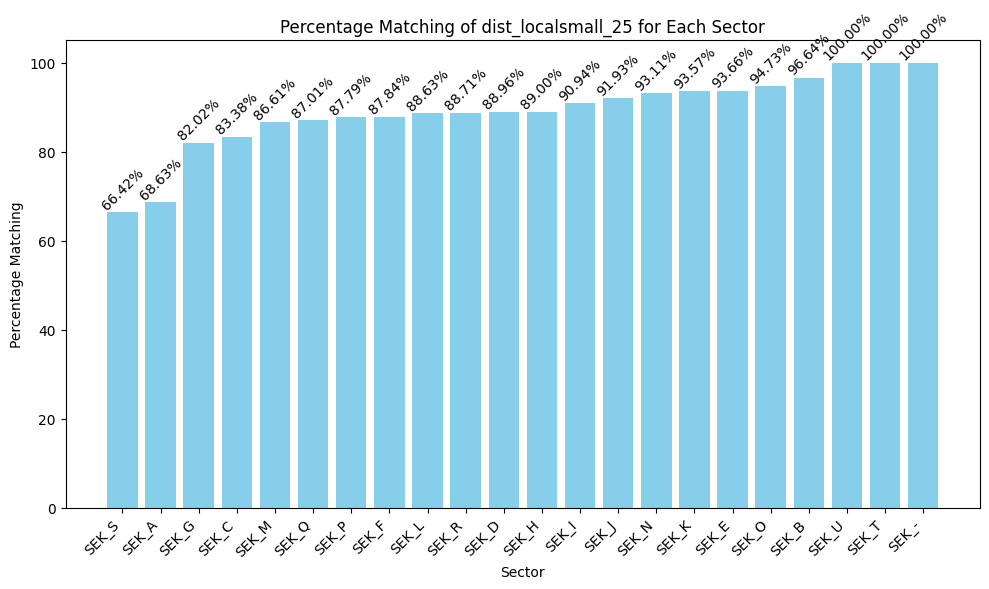

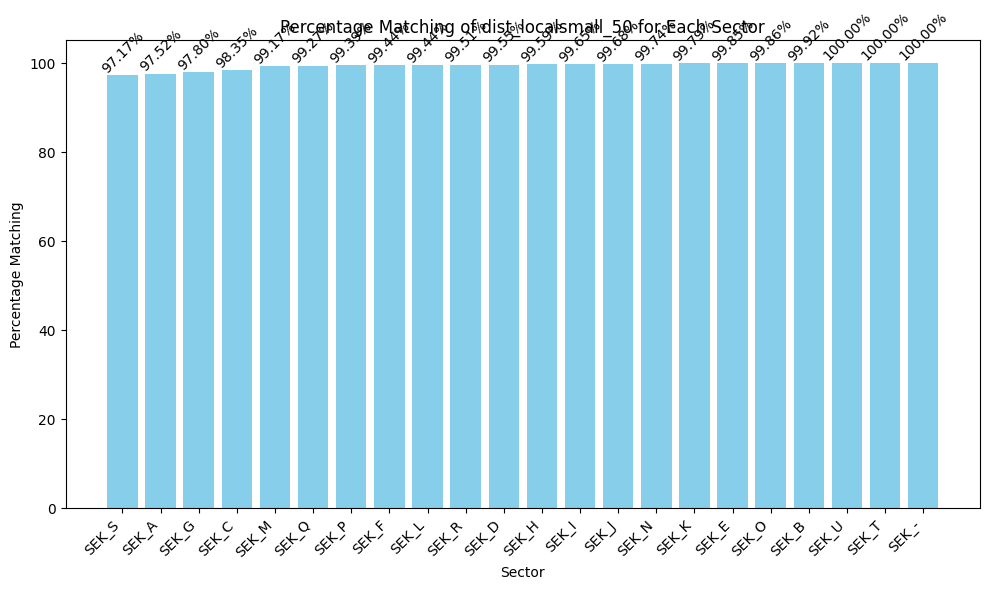

In [7]:
import matplotlib.pyplot as plt

for var in vars_list:
    percentages_matching = {}
    
    # Extract the 'Percentage Matching' for the current variable across all sectors
    for sek in sectors_list:
        # Here we access the DataFrame for the sector and then the row for the variable
        percentages_matching[sek] = results_dfs[f'results_{sek}'][results_dfs[f'results_{sek}']['Variable'] == var]['Percentage Matching'].iloc[0]
    
    labels = list(percentages_matching.keys())
    percentages = sorted([float(percentage[:-1]) for percentage in list(percentages_matching.values())])

    # Create a new figure for each variable
    plt.figure(figsize=(10, 6))
    plt.bar(labels, percentages, color='skyblue')
    plt.title(f'Percentage Matching of {var} for Each Sector')
    plt.xlabel('Sector')
    plt.ylabel('Percentage Matching')
    
    # Rotate x-axis labels
    plt.xticks(rotation=45)
    
    # Adding the percentage values on top of the bars
    for i, (label, percentage) in enumerate(zip(labels, percentages)):
        plt.text(i, percentage, f"{percentage:.2f}%", ha='center', va='bottom', rotation=45)

    # Adjust the layout and show the plot
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()
